# 1. About Dataset

## 1-1. Import Library

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd

import seaborn as sns

import warnings
warnings.filterwarnings(action='ignore')

# 데이터 분할 및 모델 선택 도구
from sklearn.model_selection import train_test_split, GridSearchCV, \
    cross_val_score,cross_validate, KFold

# 전처리 도구
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 머신러닝 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression, \
Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


# 모델 평가 지표
from sklearn.metrics import classification_report, accuracy_score, \
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, \
        r2_score,  make_scorer

## 1-2. Data Summary

In [4]:
train_df = pd.read_csv('./data/bike_train.csv', encoding='euc-kr')
test_df = pd.read_csv('./data/bike_test.csv', encoding='euc-kr')
train_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32


In [28]:
# 데이터의 결측치 확인
pd.isnull(train_df).sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
year          0
month         0
day           0
hour          0
weekday       0
dtype: int64

In [29]:
# 데이터 타입 확인
train_df.dtypes

datetime      datetime64[ns]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
year                   int32
month                  int32
day                    int32
hour                   int32
weekday                int32
dtype: object

# 2. Feature Engineering

In [31]:
# 날짜컬럼을 분리
train_df['datetime'] = pd.to_datetime(train_df['datetime'])
train_df['year'] = train_df['datetime'].dt.year
train_df['month'] = train_df['datetime'].dt.month
train_df['day'] = train_df['datetime'].dt.day
train_df['hour'] = train_df['datetime'].dt.hour
train_df['weekday'] = train_df['datetime'].dt.weekday

test_df['datetime'] = pd.to_datetime(test_df['datetime'])
test_df['year'] = test_df['datetime'].dt.year
test_df['month'] = test_df['datetime'].dt.month
test_df['day'] = test_df['datetime'].dt.day
test_df['hour'] = test_df['datetime'].dt.hour
test_df['weekday'] = test_df['datetime'].dt.weekday

In [ ]:
# 필요없어진 날짜 컬럼 제거 & 
# 캐주얼과 레지스터드의 합은 카운트 -> 테스트 데이터에는 존재하지 않으므로 제거
tr_df = train_df.drop(['datetime', 'casual', 'registered'], axis =1)

# 3. Outliner Analysis

## 3-1. 계절, 시간, 근무일별 count 수준 확인

[Text(0.5, 0, 'Working Day'),
 Text(0, 0.5, 'Count'),
 Text(0.5, 1.0, 'Box Plot On Count Across Working Day')]

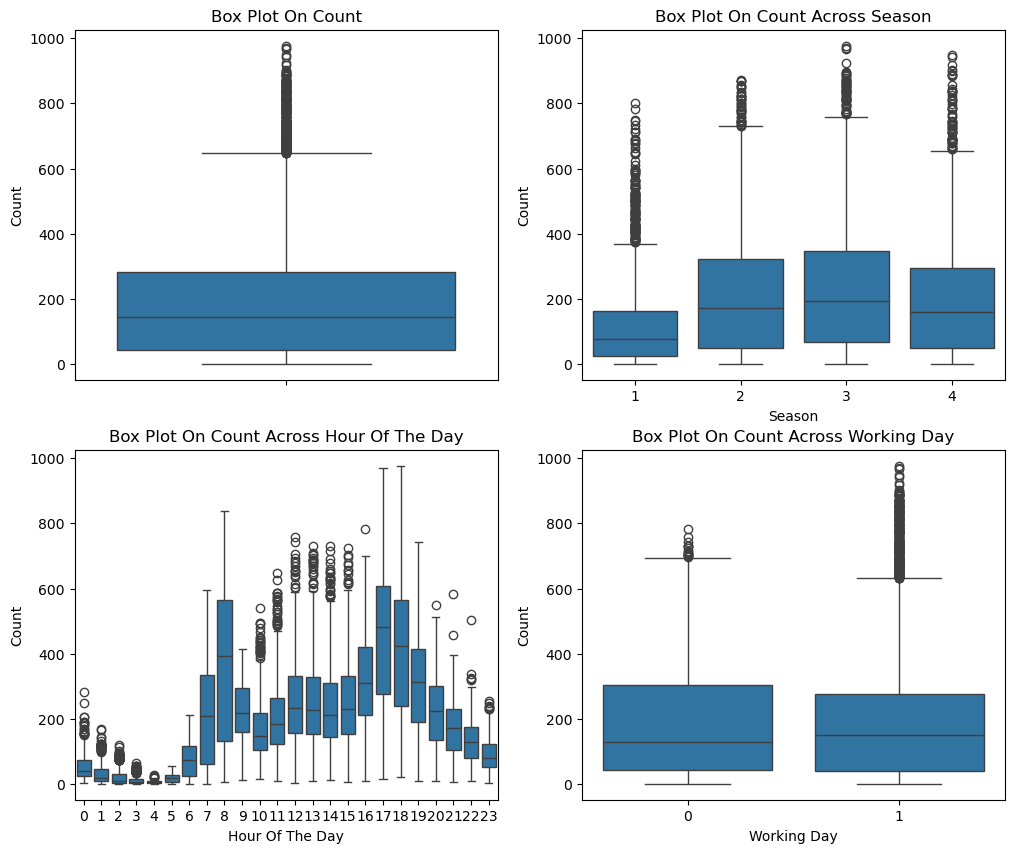

In [ ]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(12, 10)
sns.boxplot(data=tr_df,y="count",orient="v",ax=axes[0][0])
sns.boxplot(data=tr_df,y="count",x="season",orient="v",ax=axes[0][1], palette='rainbow')
sns.boxplot(data=tr_df,y="count",x="hour",orient="v",ax=axes[1][0], palette='hsv')
sns.boxplot(data=tr_df,y="count",x="workingday",orient="v",ax=axes[1][1], palette='brg')

axes[0][0].set(ylabel='Count',title="Box Plot On Count")
axes[0][1].set(xlabel='Season', ylabel='Count',title="Box Plot On Count Across Season")
axes[1][0].set(xlabel='Hour Of The Day', ylabel='Count',title="Box Plot On Count Across Hour Of The Day")
axes[1][1].set(xlabel='Working Day', ylabel='Count',title="Box Plot On Count Across Working Day")

다른 계절과 비교해서 여름, 가을에 상대적으로 많이 자전거를 대여한다는 것을 알 수 있으며 
출퇴근 시간에 대여량이 급증하는 것을 알 수가 있다. 다만 휴일과 일하는 날의 대여량 수준은 비슷한 것으로 보임

## 3-2. Count 분포 확인 

<Axes: xlabel='count', ylabel='Count'>

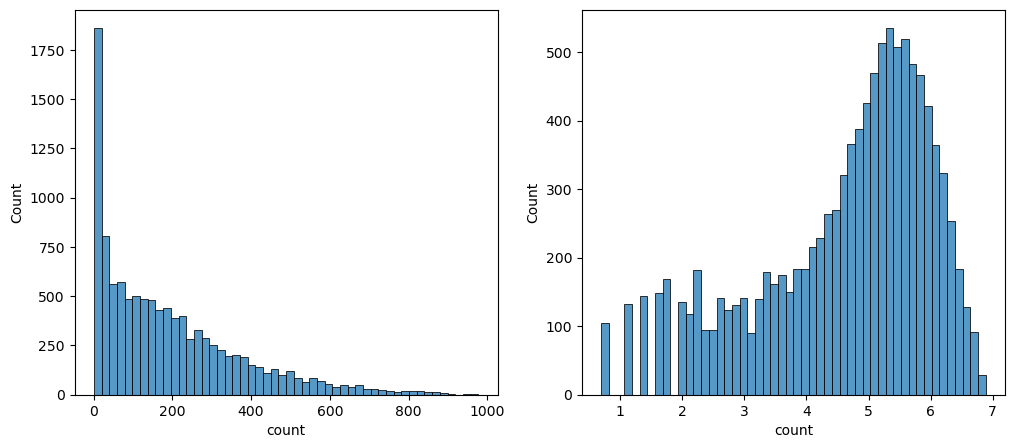

In [ ]:
fig, axes = plt.subplots(1,2)
fig.set_size_inches(12, 5)
sns.histplot(tr_df['count'], bins=50, ax=axes[0], palette='rainbow')
sns.histplot(np.log1p(tr_df['count']), bins=50, ax=axes[1], palette='rainbow')

count는 오른쪽으로 기울어지는 분포를 보임   
-> 학습 시 왜곡을 방지하기 위해 로그로 변환시킴

## 3-3. 각 독립 변수별 이상치 파악

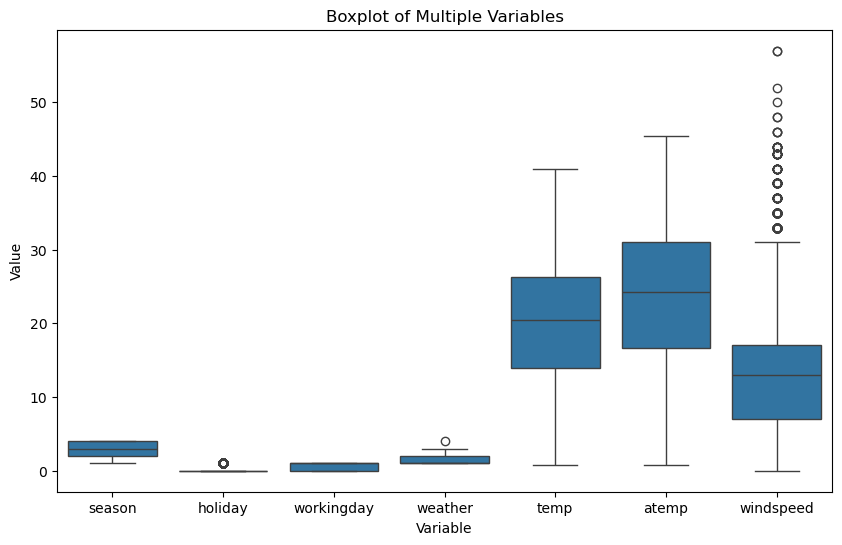

In [19]:
cols = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'windspeed']
df_melted = tr_df[cols].melt(var_name='Variable', value_name='Value')

plt.figure(figsize=(10, 6))
sns.boxplot(x='Variable', y='Value', data=df_melted)
plt.title('Boxplot of Multiple Variables')
plt.show()

위의 박스플롯을 이용해 풍속에 이상치가 다량 존재함을 확인

In [16]:
windspeed = tr_df['windspeed']

Q1 = windspeed.quantile(0.25)
Q3 = windspeed.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_idx = tr_df[(windspeed < lower_bound) | (windspeed > upper_bound)].index

print("이상치 인덱스:")
print(outlier_idx.tolist())

이상치 인덱스:
[175, 178, 194, 196, 265, 271, 471, 472, 473, 474, 479, 604, 605, 606, 608, 612, 613, 705, 749, 750, 752, 753, 754, 756, 757, 758, 760, 761, 762, 848, 850, 853, 860, 861, 862, 863, 864, 865, 866, 867, 868, 869, 870, 873, 874, 875, 919, 920, 923, 924, 929, 1015, 1017, 1022, 1023, 1108, 1151, 1307, 1313, 1380, 1409, 1410, 1411, 1412, 1413, 1415, 1423, 1427, 1428, 1433, 1437, 1440, 1456, 1577, 1578, 1579, 1582, 1595, 1601, 1674, 1694, 1695, 1696, 1697, 1699, 1721, 1838, 1839, 1840, 1853, 1887, 1889, 2268, 2274, 2275, 2525, 2755, 2756, 2963, 3200, 3307, 3479, 3480, 3595, 3596, 3720, 3953, 4403, 4406, 4494, 4495, 4496, 4594, 4760, 4761, 4763, 4812, 5129, 5130, 5131, 5314, 5456, 5480, 5481, 5482, 5483, 5485, 5487, 5712, 5713, 5719, 5720, 5721, 5722, 5723, 5817, 5818, 5819, 5829, 5830, 5831, 5832, 5833, 5839, 5842, 5843, 5916, 5918, 5919, 6132, 6133, 6134, 6135, 6137, 6140, 6141, 6142, 6150, 6152, 6153, 6417, 6418, 6419, 6420, 6421, 6444, 6449, 6491, 6511, 6512, 6513, 6514, 6515, 651

풍속에서 이상치를 가지고 있는 인덱스 반환함

# 4. Correlation Analysis

<Axes: >

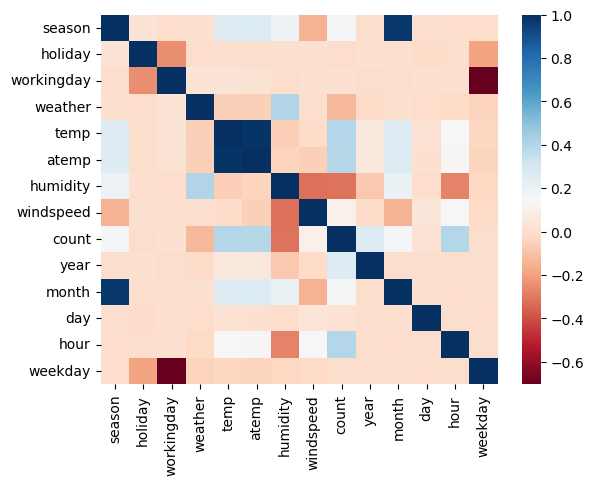

In [ ]:
corr = tr_df.corr()
sns.heatmap(corr, cmap='RdBu')

위의 상관분석 결과를 통해 각 독립변수들 간의 상관관계는 낮다는 것을 알 수 있으며     
count와 humidity의 상관관계가 낮음을 파악 할 수 있다

# 5. Eliminate outliner data

In [35]:
tr_df1 = tr_df.drop(outlier_idx, axis=0)
tr_df2 = tr_df1.drop('humidity', axis = 1)
X = tr_df2.drop('count', axis =1)
y = tr_df2['count']
y = np.log1p(y)

풍속 이상치 인덱스와 습도 컬럼 제거

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                 y, 
                 test_size= 0.3, 
                 random_state= 156)

# 6. 모델 학습 및 평가

## 6-1. LinearRegression

In [ ]:
results = []

for degree in range(1,5):
    model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False )),
    ('linear', LinearRegression())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly_log = model_poly.predict(X_test)
    pred_poly = np.expm1(pred_poly_log)
    actual = np.expm1(y_test)
    
    mse = mean_squared_error(actual, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, pred_poly)
    
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,3.055838e+04,174.809548,0.081710
1,2,1.651530e+04,128.511879,0.503710
2,3,1.907207e+04,138.101682,0.426878
3,4,inf,inf,-inf


In [57]:
alphas = [0.001, 0.01, 0.1, 1.0 ,10, 100]
ridge_cv = RidgeCV(alphas=alphas, cv = 5)
ridge_cv.fit(X_train, y_train)
ridge_preds = ridge_cv.predict(X_test)

print("MSE:", mean_squared_error(y_test, ridge_preds))
print("R2:", r2_score(y_test, ridge_preds))

MSE: 1.0969033503485568
R2: 0.4610999778125846


In [54]:
ridge_cv.alpha_

np.float64(10.0)

In [ ]:
alphas = [0.001, 0.01, 0.1, 1.0 ,10, 100]
lasso_CV = LassoCV(alphas=alphas, cv = 5)
lasso_CV.fit(X_train, y_train)
lasso_preds = lasso_CV.predict(X_test)

print("MSE:", mean_squared_error(y_test, lasso_preds))
print("R2:", r2_score(y_test, lasso_preds))

MSE: 1.097103389428028
R2: 0.4610017001800739


In [52]:
lasso_CV.alpha_

np.float64(0.001)

## 6-2. RandomForestRegressor

In [44]:
results = []

for degree in range(1,5):
    model_poly = Pipeline([
    ('poly', PolynomialFeatures(degree=degree, include_bias=False )),
    ('linear', RandomForestRegressor())]
    )
    model_poly.fit(X_train, y_train)
    pred_poly_log = model_poly.predict(X_test)
    pred_poly = np.expm1(pred_poly_log)
    actual = np.expm1(y_test)
    mse = mean_squared_error(actual, pred_poly)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, pred_poly)
    
    results.append({'degree':degree, 'MSE':mse, 'RMSE':rmse, 'R2':r2})
    
pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,1923.521537,43.857970,0.942198
1,2,1828.011382,42.755250,0.945068
2,3,1948.641487,44.143420,0.941443
3,4,2047.907404,45.253811,0.938460


In [60]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score, KFold
def rmse_exp(y_true, y_pred):
    y_true = np.expm1(y_true)
    y_pred = np.expm1(y_pred)
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse_exp, greater_is_better=False)

# ✅ 교차검증 설정
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for degree in range(1, 5):
    model_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    
    scores = cross_validate(
        model_poly,
        X_train,
        y_train,
        scoring={'rmse': rmse_scorer, 'r2': 'r2'},
        cv=cv,
        return_train_score=False
    )

    results.append({
        'degree': degree,
        'RMSE(mean)': -np.mean(scores['test_rmse']),  # 부호 반전
        'R²(mean)': np.mean(scores['test_r2'])
    })

# 결과 테이블 출력
results_df = pd.DataFrame(results)
display(results_df)

,degree,RMSE(mean),R²(mean)
0,1,46.973639,0.948708
1,2,45.805727,0.951212
2,3,47.092033,0.949220
3,4,49.204338,0.947062


## 6-3. XGBRegressor

In [42]:
from xgboost import XGBRegressor
results = []

for degree in range(1, 5):
    model_xgb = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('xgb', XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            objective='reg:squarederror',
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    # 모델 학습 (log-transformed target)
    model_xgb.fit(X_train, y_train)

    # 예측 (로그 단위)
    pred_log = model_xgb.predict(X_test)

    # 예측값 복원
    pred = np.expm1(pred_log)
    actual = np.expm1(y_test)

    # 평가
    mse = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, pred)

    results.append({
        'degree': degree,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

pd.DataFrame(results)

,degree,MSE,RMSE,R2
0,1,2136.984947,46.227535,0.935783
1,2,2059.175667,45.378141,0.938121
2,3,2194.833421,46.849049,0.934045
3,4,2205.497057,46.962720,0.933724
